In [1]:
#dependencies
!pip install kneed
# Load the required modules
import os
import scvi
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
import scanpy.external as sce
from scipy import sparse
from scipy.sparse import csr_matrix
from sklearn.decomposition import PCA
from kneed import KneeLocator as kl
import plotnine as p9
import gseapy as gp
import warnings
# Ignore the warning messages
warnings.filterwarnings("ignore")


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


/env/lib/python3.11/site-packages/torch/cuda/__init__.py:619: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


### **Functional Enrichment Analysis Summary**

Following differential expression analysis between synthetic PDAC cell populations, we performed pathway enrichment analysis using Enrichr against:

- KEGG 2021 Human

- GO Biological Process 2021

Significantly differentially expressed genes (posterior probability > 0.95 and FDR < 0.05) were used as input for enrichment analysis.

**Objective**

The purpose of this step is to evaluate whether transcriptional differences identified between synthetic cell populations are not only statistically significant, but also biologically meaningful.

If enriched pathways correspond to expected PDAC-related processes — such as:

- Epithelial differentiation

- EMT-related programs

- Immune signaling pathways

- Cell cycle regulation

- Metabolic reprogramming

— this provides functional evidence that the generative model preserves biologically coherent gene programs rather than generating random transcriptional variation.

**Interpretation**

Pathway enrichment analysis therefore serves as a functional validation layer:

Differential expression → tests statistical separability

Marker gene recovery → tests cell identity preservation

Pathway enrichment → tests biological program coherence

Together, these analyses assess whether the synthetic PDAC dataset retains structured and interpretable cellular heterogeneity consistent with real tumor biology.

In [ ]:
# ----------------------------------------------------------------------------------
# convert_synthetic_to_counts
# ----------------------------------------------------------------------------------
# Purpose:
# Convert synthetic log-normalized expression values into count-like matrices by
# matching the library-size (total counts per cell) distribution observed in real data.
#
# Rationale:
# LVAE produces log-normalized expression. To run downstream workflows that
# assume counts (or to simulate realistic count depth), we rescale synthetic cells
# using library-size factors sampled from the real PDAC dataset.
#
# Method:
# 1) Subset real cells for the target cell type (reference distribution).
# 2) Compute real library size factors (sum of counts per cell).
# 3) Fit a log-normal distribution to the real scaling factors.
# 4) Sample synthetic scaling factors from this distribution.
# 5) Invert log1p on synthetic expression (expm1), rescale by sampled factors,
#    and round to integer non-negative values.
#
# Output:
# Returns a copy of the synthetic AnnData with .X replaced by count-like integers.
# ----------------------------------------------------------------------------------

def convert_synthetic_to_counts(adata_real, adata_sint, cell_type_key="cell_type", seed=None):
    if seed is not None:
        np.random.seed(seed)

    ad_sint_ct = adata_sint.copy()
    ad_real_ct = adata[adata.obs["cell_type"] == cell_type_key].copy()

    if ad_real_ct.shape[0] == 0 or ad_sint_ct.shape[0] == 0:
        print(f"Skipping {cell_type_key}: no data.")
        return 0

    # Obtener counts reales
    #ad_real_ct.X = ad_real_ct.layers["counts"]
    real_size_factors = ad_real_ct.X.sum(axis=1).A1 if sparse.issparse(ad_real_ct.X) else ad_real_ct.X.sum(axis=1)
    normalized_sum = 1e4
    real_scale_factors = real_size_factors / normalized_sum

    # Parámetros log-normales
    log_sf = np.log(real_scale_factors)
    mu, sigma = np.mean(log_sf), np.std(log_sf)

    # Muestreo de nuevos factores
    n_sint = ad_sint_ct.shape[0]
    synthetic_factors = np.random.lognormal(mean=mu, sigma=sigma, size=n_sint)

    # Revertir log1p -> expm1
    if sparse.issparse(ad_sint_ct.X):
        X_deno = np.expm1(ad_sint_ct.X.todense())
    else:
        X_deno = np.expm1(ad_sint_ct.X)

    # Aplicar factores de escala
    X_counts = X_deno * synthetic_factors[:, np.newaxis]

    # Redondear y asegurar que no haya negativos
    X_counts = np.rint(np.maximum(X_counts, 0)).astype(int)

    # Sustituir en la copia
    ad_sint_ct.X = X_counts
    print(ad_sint_ct.X.max(), ad_sint_ct.X.min())

    return ad_sint_ct

### ADATA REAL

In [3]:
# Load real PDAC AnnData (reference dataset used to estimate library-size distribution)
adata = sc.read_h5ad("/home/app/datos/PENG/adata_raw_anotado_peng_julio.h5ad")
adata.obs["cell_origin"] = "real"

### ADATA LVAE

In [4]:
# Load synthetic PDAC AnnData generated by LVAE model
adata_lvae = sc.read_h5ad("/home/app/ACTIVA/homo sapiens/articulo/articulo_def/figuras_final/DEA/peng_etiquetado.h5ad")
adata_lvae.obs["cell_origin"] = "sintetico"

In [ ]:
#Real data preprocessing (reference)
# Perform basic QC on the real dataset and preserve raw counts before normalization.
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

# Store raw counts in a dedicated layer and keep a .raw snapshot
adata.layers["counts"] = csr_matrix(adata.X)
adata.raw = adata

# Normalize to fixed depth and log-transform
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)


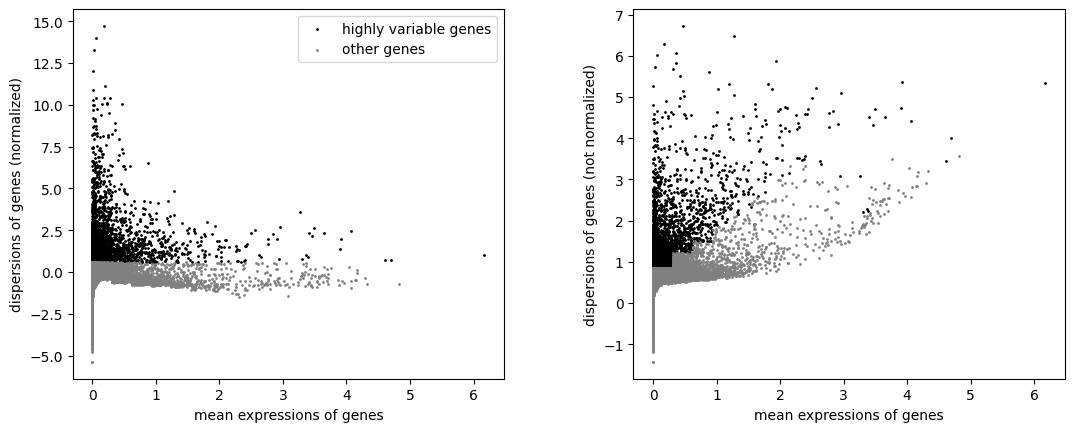

In [6]:
# Select highly variable genes (HVGs) to focus downstream analyses
sc.pp.highly_variable_genes(adata,n_top_genes=3000)
sc.pl.highly_variable_genes(adata)
# Subset to HVGs
adata = adata[:, adata.var.highly_variable].copy()

In [7]:
# Save list of highly variable genes (HVGs)
hvg = list(adata.var_names)

In [8]:
#Reload ADATA REAL
adata = sc.read_h5ad("/home/app/datos/PENG/adata_raw_anotado_peng_julio.h5ad")
adata.obs["cell_origin"] = "real"

In [9]:
# Perform basic QC on the real dataset
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

#HVGs filtering
adata = adata[:, adata.var_names.isin(hvg)].copy()

In [10]:
# Split synthetic dataset into cell-type-specific AnnData objects
# This enables applying cell-type-specific library-size scaling based on real data.
acinar = adata_lvae[adata_lvae.obs['cell_type'].isin(['Acinar cell Cholesky'])].copy()
classical = adata_lvae[adata_lvae.obs['cell_type'].isin(['Tumoral - Classical Cholesky'])].copy()
monocytes = adata_lvae[adata_lvae.obs['cell_type'].isin(['Monocytes Cholesky'])].copy()
basal = adata_lvae[adata_lvae.obs['cell_type'].isin(['Tumoral - Basal-like Cholesky'])].copy()
endothelial = adata_lvae[adata_lvae.obs['cell_type'].isin(['Endothelial cells Cholesky'])].copy()
macrophages = adata_lvae[adata_lvae.obs['cell_type'].isin(['Macrophages Cholesky'])].copy()
b = adata_lvae[adata_lvae.obs['cell_type'].isin(['B cell Cholesky'])].copy()
dendritic = adata_lvae[adata_lvae.obs['cell_type'].isin(['Dendritic cells Cholesky'])].copy()
proliferative = adata_lvae[adata_lvae.obs['cell_type'].isin(['Proliferative cells Cholesky'])].copy()
ribosomal = adata_lvae[adata_lvae.obs['cell_type'].isin(['Ribosomal cells Cholesky'])].copy()
endocrine = adata_lvae[adata_lvae.obs['cell_type'].isin(['Endocrine cells Cholesky'])].copy()
ductal = adata_lvae[adata_lvae.obs['cell_type'].isin(['Ductal cell Cholesky'])].copy()
fibroblast = adata_lvae[adata_lvae.obs['cell_type'].isin(['Fibroblast Cholesky'])].copy()
mast = adata_lvae[adata_lvae.obs['cell_type'].isin(['Mast cells Cholesky'])].copy()
plasma = adata_lvae[adata_lvae.obs['cell_type'].isin(['Plasma cells Cholesky'])].copy()
t_cd4 = adata_lvae[adata_lvae.obs['cell_type'].isin(['T CD4 Cholesky'])].copy()
t_cd8 = adata_lvae[adata_lvae.obs['cell_type'].isin(['T CD8 Cholesky'])].copy()
reg = adata_lvae[adata_lvae.obs['cell_type'].isin(['T CD4 Reg Cholesky'])].copy()
caf = adata_lvae[adata_lvae.obs['cell_type'].isin(['CAF Cholesky'])].copy()

In [11]:
# Convert synthetic log-normalized expression to count-like values
# For each synthetic cell type, sample library-size scaling factors from the corresponding
# real cell type and rescale synthetic expression accordingly.
acinar = convert_synthetic_to_counts(adata, acinar, "Acinar cell")
classical = convert_synthetic_to_counts(adata, classical, "Tumoral - Classical")
monocytes = convert_synthetic_to_counts(adata, monocytes, "Monocytes")
basal = convert_synthetic_to_counts(adata, basal, "Tumoral - Basal-like")
endothelial = convert_synthetic_to_counts(adata, endothelial, "Endothelial cells")
macrophages = convert_synthetic_to_counts(adata, macrophages, "Macrophages")
b = convert_synthetic_to_counts(adata, b, "B cell")
dendritic = convert_synthetic_to_counts(adata, dendritic, "Dendritic cells")
proliferative = convert_synthetic_to_counts(adata, proliferative, "Proliferative cells")
ribosomal = convert_synthetic_to_counts(adata, ribosomal, "Ribosomal cells")
endocrine = convert_synthetic_to_counts(adata, endocrine, "Endocrine cells")
ductal = convert_synthetic_to_counts(adata, ductal, "Ductal cell")
fibroblast = convert_synthetic_to_counts(adata, fibroblast, "Fibroblast")
mast = convert_synthetic_to_counts(adata, mast, "Mast cells")
plasma = convert_synthetic_to_counts(adata, plasma, "Plasma cells")
t_cd4 = convert_synthetic_to_counts(adata, t_cd4, "T CD4")
t_cd8 = convert_synthetic_to_counts(adata, t_cd8, "T CD8")
reg = convert_synthetic_to_counts(adata, reg, "T CD4 Reg")
caf = convert_synthetic_to_counts(adata, caf, "CAF")

6527 0
10250 0
1155 0
8756 0
5546 0
6131 0
3683 0
2359 0
4541 0
1182 0
2420 0
4466 0
3984 0
2865 0
2349 0
1230 0
2752 0
2754 0
3961 0


In [ ]:
# Concatenate all synthetic cell-type subsets into one unified synthetic dataset
sintetic_data = sc.concat([acinar, b, dendritic, ductal, endocrine, endothelial, caf,
                               macrophages, monocytes, fibroblast, mast, t_cd8, t_cd4,
                               reg, basal, classical, proliferative, ribosomal, plasma])

In [75]:
sintetic_data

AnnData object with n_obs × n_vars = 45799 × 3000
    obs: 'Sample', 'cell_type', 'cell_origin', 'Sample_pred_conf', 'Sample_pred_margin', 'Sample_pred_lowconf', 'Sample_pred_pass'
    obsm: 'X_pca', 'X_umap'

In [78]:
sintetic_data

AnnData object with n_obs × n_vars = 45799 × 3000
    obs: 'Sample', 'cell_type', 'cell_origin', 'Sample_pred_conf', 'Sample_pred_margin', 'Sample_pred_lowconf', 'Sample_pred_pass'
    obsm: 'X_pca', 'X_umap'

In [80]:
# Learn a latent representation of the synthetic dataset with scVI
# -------------------------------------------------------
# scVI is used here to obtain a denoised latent space representation, which improves
# visualization and provides a structured embedding for neighborhood-based analyses.

scvi.model.SCVI.setup_anndata(sintetic_data, batch_key="Sample")  # prepare data for scVI
model = scvi.model.SCVI(sintetic_data, gene_likelihood="nb")

# Train the model
model.train(
    check_val_every_n_epoch=1,
    max_epochs=400,
    early_stopping=True,
    early_stopping_patience=20,
    early_stopping_monitor="elbo_validation",
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 361/400:  90%|██████████████████████████████████████████████████████████████████▊       | 361/400 [17:32<01:53,  2.92s/it, v_num=1, train_loss_step=1.15e+3, train_loss_epoch=522]
Monitored metric elbo_validation did not improve in the last 20 records. Best score: 523.968. Signaling Trainer to stop.


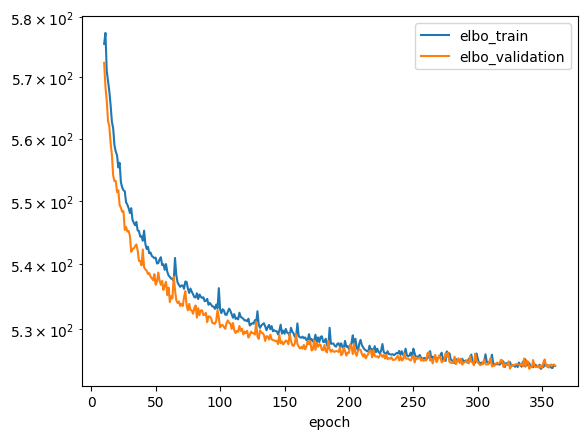

In [81]:
# Plot training/validation ELBO to verify convergence
train_test_results = model.history["elbo_train"]
train_test_results["elbo_validation"] = model.history["elbo_validation"]
train_test_results.iloc[10:].plot(logy=True)  # exclude first 10 epochs
plt.show()

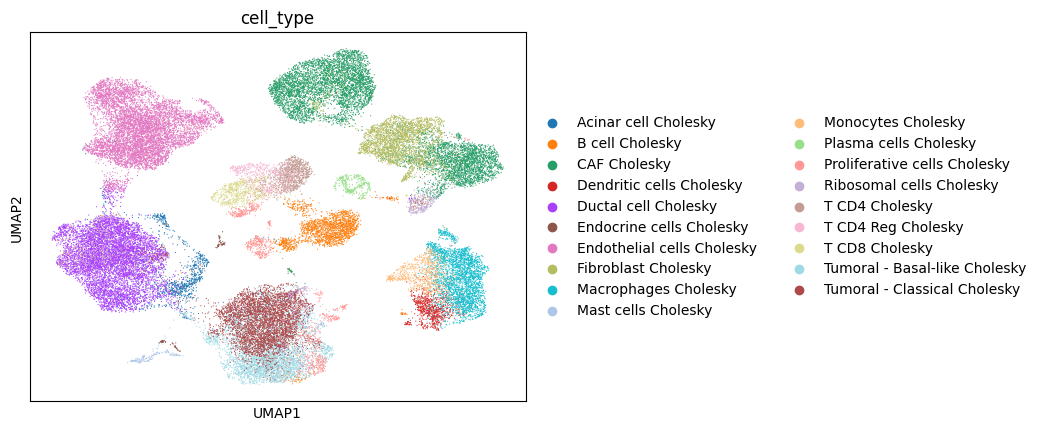

In [83]:
# Compute UMAP using the scVI latent representation for visualization
SCVI_LATENT_KEY = "X_scVI"

latent = model.get_latent_representation()
sintetic_data.obsm[SCVI_LATENT_KEY] = latent
sc.pp.neighbors(sintetic_data, use_rep=SCVI_LATENT_KEY)
sc.tl.umap(sintetic_data)
# Visualize synthetic cell groups in the learned latent space
sc.pl.umap(sintetic_data, color="cell_type")

In [ ]:
# Standardize cell-type naming by removing the " Cholesky" suffix
sintetic_data.obs["cell_type"] = (
    sintetic_data.obs["cell_type"]
    .astype(str)
    .str.replace(" Cholesky", "", regex=False)
)

# Convert back to categorical for clean category handling downstream
sintetic_data.obs["cell_type"] = pd.Categorical(sintetic_data.obs["cell_type"])

In [82]:
# Sanity check: number of cells in specific synthetic cell-type groups
cell_type_1 = "Tumoral - Basal-like"
cell_idx1 = sintetic_data.obs["cell_type"] == cell_type_1
print(sum(cell_idx1), "cells of type", cell_type_1)

cell_type_2 = "Tumoral - Classical"
cell_idx2 = sintetic_data.obs["cell_type"] == cell_type_2
print(sum(cell_idx2), "cells of type", cell_type_2)

4188 cells of type Tumoral - Classical Cholesky
4133 cells of type Tumoral - Basal-like Cholesky


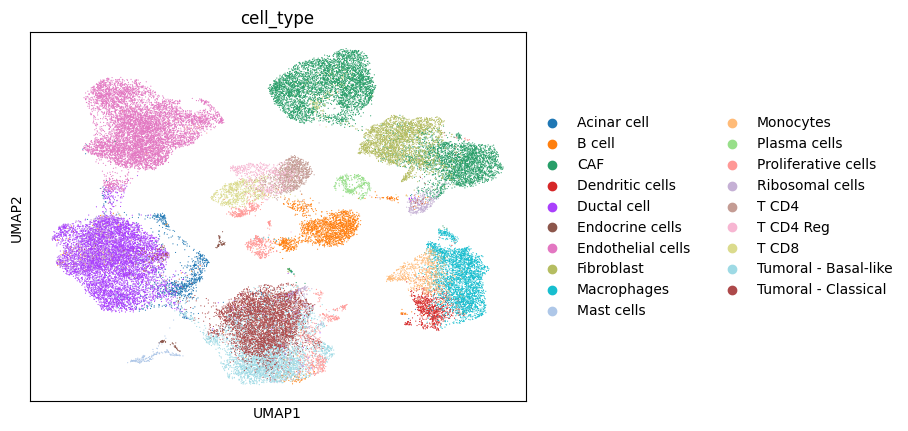

In [117]:
sc.pl.umap(sintetic_data, color="cell_type", save = "scvi_figure")

In [84]:
# Differential expression (pairwise): synthetic group 1 vs synthetic group 2
# scVI provides a Bayesian DE test operating in the learned generative space.
de_change = model.differential_expression(idx1=cell_idx1, idx2=cell_idx2)
de_change

DE...: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.08s/it]


,proba_de,proba_not_de,bayes_factor,scale1,scale2,pseudocounts,delta,lfc_mean,lfc_median,lfc_std,lfc_min,lfc_max,raw_mean1,raw_mean2,non_zeros_proportion1,non_zeros_proportion2,raw_normalized_mean1,raw_normalized_mean2,is_de_fdr_0.05
WISP2,0.9862,0.0138,4.269190,8.713034e-08,2.304312e-08,0.0,0.25,3.085037,3.230429,11.889889,-39.343422,37.562611,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,True
DPT,0.9848,0.0152,4.171142,1.971867e-07,2.794553e-08,0.0,0.25,0.277002,0.176937,11.943186,-40.489563,37.747406,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,True
FGF7,0.9844,0.0156,4.144761,9.408976e-07,5.305532e-08,0.0,0.25,3.256823,3.257977,11.291398,-36.552261,40.950394,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,True
PLA2G2A,0.9840,0.0160,4.119037,2.309349e-07,9.291350e-08,0.0,0.25,2.171631,2.352262,11.349524,-37.682545,35.550762,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,True
COL8A1,0.9838,0.0162,4.106411,1.360931e-06,1.236126e-07,0.0,0.25,5.291884,5.487803,11.881496,-41.190590,41.994164,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SMIM14,0.7992,0.2008,1.381302,4.420429e-04,3.994595e-04,0.0,0.25,0.140940,0.118730,1.181352,-4.284528,5.016961,1.078797,1.151706,0.595511,0.599564,4.716019,4.184498,True
MT-CO1,0.7864,0.2136,1.303360,4.762767e-02,6.119243e-02,0.0,0.25,-0.383767,-0.389827,0.825051,-3.278291,2.417888,107.097660,173.240019,0.999761,1.000000,460.838797,652.145522,True
S100A6,0.7864,0.2136,1.303360,7.528321e-02,7.768337e-02,0.0,0.25,-0.107153,-0.059989,1.153296,-7.009493,4.789613,175.973257,215.088314,0.997851,1.000000,780.253310,807.949437,True
HSP90AA1,0.7738,0.2262,1.229894,4.709993e-03,4.482783e-03,0.0,0.25,0.051882,0.060427,0.890972,-3.196494,4.124581,10.821633,10.980160,0.990926,0.991290,46.811433,41.332938,True


In [ ]:
# DE with uniform weighting and batch correction
# - weights="uniform": each cell contributes equally to the DE estimate
# - batch_correction=True: attempts to remove batch effects when estimating DE

de_change_uniform = model.differential_expression(
    idx1=cell_idx1,
    idx2=cell_idx2,
    weights="uniform",
    batch_correction=True,
)

# Create a plotting-friendly significance score.
# scVI reports posterior probabilities; here we transform proba_not_de into log10 space.
# (Higher -log10(proba_not_de) indicates stronger evidence for DE.)
de_change_uniform["log10_pscore"] = np.log10(de_change_uniform["proba_not_de"])
de_change_uniform = de_change_uniform.join(adata.var, how="inner")
de_change_uniform.head()

DE...: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:10<00:00, 10.33s/it]


,proba_de,proba_not_de,bayes_factor,scale1,scale2,pseudocounts,delta,lfc_mean,lfc_median,lfc_std,...,lfc_max,raw_mean1,raw_mean2,non_zeros_proportion1,non_zeros_proportion2,raw_normalized_mean1,raw_normalized_mean2,is_de_fdr_0.05,log10_pscore,n_cells
COL8A1,0.985513,0.014487,4.219915,8.683735e-07,5.774274e-08,0.0,0.25,5.793211,5.937270,11.204940,...,43.525009,0.0,0.0,0.0,0.0,0.0,0.0,True,-1.839024,5524
DPT,0.984105,0.015895,4.125704,4.242244e-07,1.651666e-07,0.0,0.25,0.064500,-0.053270,10.465693,...,35.422256,0.0,0.0,0.0,0.0,0.0,0.0,True,-1.798729,4039
ABCA8,0.982495,0.017505,4.027606,1.212325e-07,5.628854e-08,0.0,0.25,-0.253868,-0.514262,9.361624,...,33.682739,0.0,0.0,0.0,0.0,0.0,0.0,True,-1.756837,2957
WISP2,0.981891,0.018109,3.993090,1.703488e-07,5.701360e-08,0.0,0.25,3.342177,3.304098,10.027011,...,34.053558,0.0,0.0,0.0,0.0,0.0,0.0,True,-1.742114,1257
FGF7,0.981891,0.018109,3.993090,3.720519e-07,4.423653e-08,0.0,0.25,3.206224,3.355308,10.382909,...,36.449394,0.0,0.0,0.0,0.0,0.0,0.0,True,-1.742114,4985


In [ ]:
# DE with importance weighting
# - weights="importance": reweights cells to focus on those most informative for the contrast
# - filter_outlier_cells=True: reduces influence of outlier cells on DE estimates
# - batch_correction=False: DE is computed without batch adjustment in this flavor

de_change_importance = model.differential_expression(
    idx1=cell_idx1,
    idx2=cell_idx2,
    weights="importance",
    filter_outlier_cells=True,
    batch_correction=False,
)

# manipulate the DE results for plotting
de_change_importance["log10_pscore"] = np.log10(de_change_importance["proba_not_de"])
de_change_importance = de_change_importance.join(adata.var, how="inner")


DE...: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:18<00:00, 18.33s/it]


In [87]:
de_change_importance

,proba_de,proba_not_de,bayes_factor,scale1,scale2,pseudocounts,delta,lfc_mean,lfc_median,lfc_std,...,lfc_max,raw_mean1,raw_mean2,non_zeros_proportion1,non_zeros_proportion2,raw_normalized_mean1,raw_normalized_mean2,is_de_fdr_0.05,log10_pscore,n_cells
ISG15,1.0000,0.0000,18.420681,5.630248e-03,1.188257e-03,0.0,0.25,2.248277,2.250528,0.165958,...,4.652727,6.005731,5.481490,0.766476,0.755625,27.391235,20.837440,True,-inf,27903
CCL4,1.0000,0.0000,18.420681,5.132210e-04,2.101480e-05,0.0,0.25,4.613195,4.632584,0.124648,...,5.528380,0.173114,0.197919,0.129656,0.137430,0.661354,0.619885,True,-inf,11497
RP11-214O1.3,1.0000,0.0000,18.420681,1.313694e-08,1.598179e-10,0.0,0.25,6.367289,6.393456,0.230681,...,8.597851,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,True,-inf,302
PMP22,1.0000,0.0000,18.420681,1.244876e-04,1.101998e-06,0.0,0.25,6.832997,6.813107,0.227008,...,7.756016,0.066380,0.055892,0.038204,0.044520,0.241131,0.152604,True,-inf,15744
TNFRSF13B,1.0000,0.0000,18.420681,1.073670e-10,3.800824e-11,0.0,0.25,1.503838,1.518913,0.314392,...,5.541050,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,True,-inf,462
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AKNA,0.0210,0.9790,-3.842009,1.057543e-05,1.133645e-05,0.0,0.25,-0.100594,-0.099665,0.090465,...,0.500473,0.027937,0.035809,0.022684,0.024921,0.098011,0.105994,True,-0.009217,4789
KCNQ1OT1,0.0210,0.9790,-3.842009,1.066404e-04,1.255535e-04,0.0,0.25,-0.233527,-0.233754,0.090388,...,-0.045716,0.943171,0.673361,0.435291,0.360271,3.944893,2.183786,True,-0.009217,14988
HLA-DPA1,0.0204,0.9796,-3.871609,4.909189e-04,5.496271e-04,0.0,0.25,-0.162417,-0.172091,0.073480,...,0.609504,1.083572,2.005565,0.425024,0.554561,4.461771,7.275993,True,-0.008951,27256
GABRP,0.0100,0.9900,-4.595119,6.722911e-05,5.824482e-05,0.0,0.25,0.208418,0.216462,0.142699,...,2.092946,1.610554,1.471570,0.315186,0.332688,6.735189,5.448381,True,-0.004365,5722


In [88]:
# Compare DE results across flavors (importance vs uniform)
# Concatenate the two DE result tables and tag each row with the DE "flavor"
de_comp = pd.concat(
    [
        de_change_importance.assign(flavor="importance"),
        de_change_uniform.assign(flavor="uniform"),
    ]
)

In [89]:
de_comp.columns

Index(['proba_de', 'proba_not_de', 'bayes_factor', 'scale1', 'scale2',
       'pseudocounts', 'delta', 'lfc_mean', 'lfc_median', 'lfc_std', 'lfc_min',
       'lfc_max', 'raw_mean1', 'raw_mean2', 'non_zeros_proportion1',
       'non_zeros_proportion2', 'raw_normalized_mean1', 'raw_normalized_mean2',
       'is_de_fdr_0.05', 'log10_pscore', 'n_cells', 'flavor'],
      dtype='object')

In [90]:
# Annotate specific gene families to highlight in the volcano-like plot
# This is purely for visualization/interpretability (does not affect DE computation).
de_comp["gene_type"] = "Other"
de_comp.loc[lambda x: x.index.str.contains("HLA-"), "gene_type"] = "HLA"
de_comp.loc[lambda x: x.index.str.contains("TLR"), "gene_type"] = "TLR"
de_comp.loc[lambda x: x.index.str.contains("APP-"), "gene_type"] = "APP"


In [91]:
de_comp

,proba_de,proba_not_de,bayes_factor,scale1,scale2,pseudocounts,delta,lfc_mean,lfc_median,lfc_std,...,raw_mean2,non_zeros_proportion1,non_zeros_proportion2,raw_normalized_mean1,raw_normalized_mean2,is_de_fdr_0.05,log10_pscore,n_cells,flavor,gene_type
ISG15,1.000000,0.000000,18.420681,5.630248e-03,1.188257e-03,0.0,0.25,2.248277,2.250528,0.165958,...,5.481490,0.766476,0.755625,27.391235,20.837440,True,-inf,27903,importance,Other
CCL4,1.000000,0.000000,18.420681,5.132210e-04,2.101480e-05,0.0,0.25,4.613195,4.632584,0.124648,...,0.197919,0.129656,0.137430,0.661354,0.619885,True,-inf,11497,importance,Other
RP11-214O1.3,1.000000,0.000000,18.420681,1.313694e-08,1.598179e-10,0.0,0.25,6.367289,6.393456,0.230681,...,0.000000,0.000000,0.000000,0.000000,0.000000,True,-inf,302,importance,Other
PMP22,1.000000,0.000000,18.420681,1.244876e-04,1.101998e-06,0.0,0.25,6.832997,6.813107,0.227008,...,0.055892,0.038204,0.044520,0.241131,0.152604,True,-inf,15744,importance,Other
TNFRSF13B,1.000000,0.000000,18.420681,1.073670e-10,3.800824e-11,0.0,0.25,1.503838,1.518913,0.314392,...,0.000000,0.000000,0.000000,0.000000,0.000000,True,-inf,462,importance,Other
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NEAT1,0.745473,0.254527,1.074611,1.456247e-02,1.099508e-02,0.0,0.25,0.406812,0.395047,0.662618,...,33.583112,1.000000,0.987902,177.836014,128.387842,False,-0.594266,41644,uniform,Other
CTSB,0.739638,0.260362,1.044087,1.021904e-03,8.864679e-04,0.0,0.25,0.162322,0.191472,0.780014,...,3.696830,0.876074,0.879990,15.947358,13.915490,False,-0.584422,31328,uniform,Other
MT-CO1,0.706439,0.293561,0.878150,5.680118e-02,6.744087e-02,0.0,0.25,-0.273491,-0.268777,0.631545,...,173.240019,0.999761,1.000000,460.838797,652.145522,False,-0.532301,42171,uniform,Other
HSP90AA1,0.682495,0.317505,0.765261,7.256601e-03,7.309827e-03,0.0,0.25,-0.020622,-0.011664,0.627026,...,10.980160,0.990926,0.991290,46.811433,41.332938,False,-0.498249,40014,uniform,Other


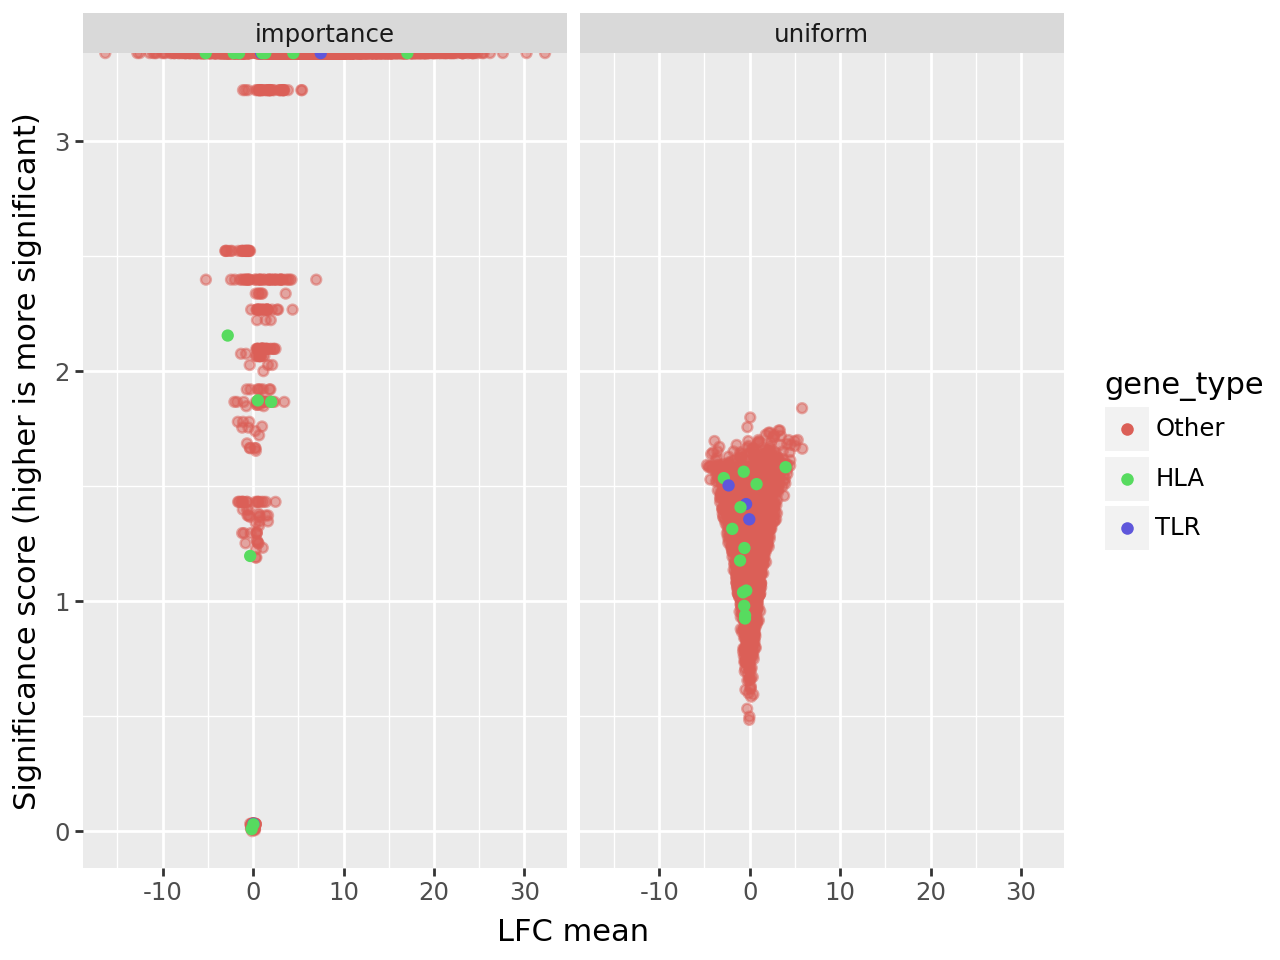

In [92]:
# Volcano-like visualization of scVI DE results
# -------------------------------------------------------
# x-axis: mean log-fold change (lfc_mean)
# y-axis: transformed posterior significance score (-log10_pscore)
# Faceting compares how gene ranking changes with different DE flavors.

(
(
    p9.ggplot(de_comp, p9.aes("lfc_mean", "-log10_pscore", color="gene_type"))
    + p9.geom_point(
        de_comp.query("gene_type == 'Other'"), alpha=0.5
    )  # Plot other genes with transparence
    + p9.geom_point(de_comp.query("gene_type != 'Other'"))
    + p9.labs(x="LFC mean", y="Significance score (higher is more significant)")
    + p9.facet_wrap("flavor")
)


In [93]:
# One-vs-rest DE across all synthetic cell types
# This performs a 1-vs-all test for each level of `cell_type` and returns a single
# concatenated DataFrame containing DE results for every comparison.
change_per_cluster_de = model.differential_expression(groupby="cell_type")

DE...: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 19/19 [00:55<00:00,  2.90s/it]


In [94]:
# Summarize number of cells per synthetic cell type
cell_types = (
    sintetic_data.obs["cell_type"]
    .value_counts()
    # .loc[lambda x: (x >= 500) & (x.index != "nan")]
    .loc[lambda x: x.index != "nan"]
    .to_frame("n_cells")
)
# scVI names comparisons as "<group> vs Rest"
cell_types.loc[:, "associated_test"] = cell_types.index.astype(str) + " vs Rest"

In [95]:
# Marker gene extraction (top upregulated genes per cell type)
# For each "<cell_type> vs Rest" comparison, select the top 5 genes by lfc_mean.
marker_genes = (
    change_per_cluster_de.reset_index()
    .loc[lambda x: x.comparison.isin(cell_types.associated_test.values)]
    .groupby("comparison")
    .apply(
        lambda x: x.sort_values("lfc_mean", ascending=False).iloc[:5]
    )  # Select top 5 DE genes per comparison
    .reset_index(drop=True)["index"]
    .unique()
)

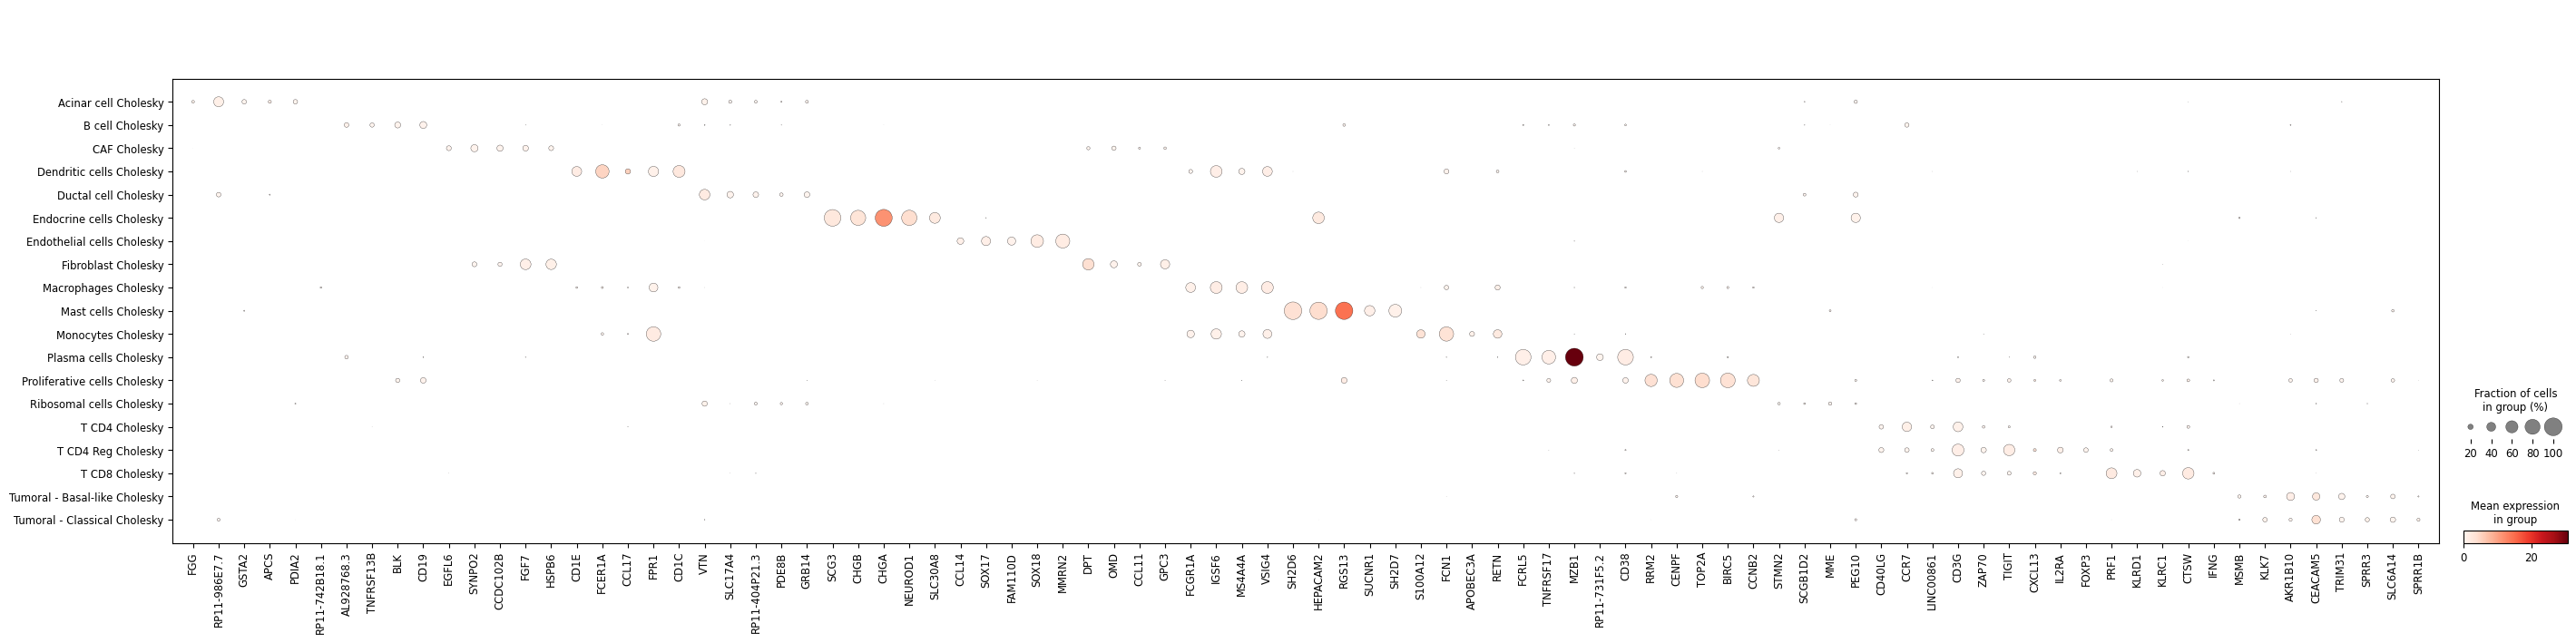

In [96]:
# Subset to valid cell types and visualize marker gene expression patterns
adata_log = sintetic_data[sintetic_data.obs.cell_type.isin(cell_types.index.values)].copy()
# Dotplot summarizes expression and fraction of expressing cells per group
sc.pl.dotplot(adata_log, marker_genes, groupby="cell_type")

In [97]:
# Filter significant DE genes for the selected pairwise comparison
# - proba_de > 0.95: high posterior probability of being differentially expressed
# - is_de_fdr_0.05 == True: passes FDR threshold at 5%
degs_df = de_change[(de_change['proba_de'] > 0.95) & (de_change['is_de_fdr_0.05'] == True)]

In [98]:
degs_df

,proba_de,proba_not_de,bayes_factor,scale1,scale2,pseudocounts,delta,lfc_mean,lfc_median,lfc_std,lfc_min,lfc_max,raw_mean1,raw_mean2,non_zeros_proportion1,non_zeros_proportion2,raw_normalized_mean1,raw_normalized_mean2,is_de_fdr_0.05
WISP2,0.9862,0.0138,4.269190,8.713034e-08,2.304312e-08,0.0,0.25,3.085037,3.230429,11.889889,-39.343422,37.562611,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,True
DPT,0.9848,0.0152,4.171142,1.971867e-07,2.794553e-08,0.0,0.25,0.277002,0.176937,11.943186,-40.489563,37.747406,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,True
FGF7,0.9844,0.0156,4.144761,9.408976e-07,5.305532e-08,0.0,0.25,3.256823,3.257977,11.291398,-36.552261,40.950394,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,True
PLA2G2A,0.9840,0.0160,4.119037,2.309349e-07,9.291350e-08,0.0,0.25,2.171631,2.352262,11.349524,-37.682545,35.550762,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,True
COL8A1,0.9838,0.0162,4.106411,1.360931e-06,1.236126e-07,0.0,0.25,5.291884,5.487803,11.881496,-41.190590,41.994164,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ADAM29,0.9502,0.0498,2.948657,4.572132e-09,5.467580e-09,0.0,0.25,-0.478060,-0.492233,4.322185,-15.894232,13.857805,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,True
DDIT4L,0.9502,0.0498,2.948657,4.912876e-09,5.234316e-09,0.0,0.25,-0.202186,-0.147135,4.200559,-14.022247,13.589649,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,True
TREML2,0.9502,0.0498,2.948657,4.567113e-09,5.012660e-09,0.0,0.25,-0.337887,-0.328173,4.242005,-14.871403,13.366713,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,True
IGFBP5,0.9502,0.0498,2.948657,1.192470e-04,4.095780e-05,0.0,0.25,0.425516,0.330004,4.279193,-15.247910,14.899204,0.221824,0.108154,0.084527,0.067989,0.836673,0.387937,True


In [99]:
# Sanity check: presence of known marker genes in the DE set
genes = ["GATA6", "TP63", "KRT14", "HNF1A", "VIM","S100A2", "KRT5", "KRT14", "KRT6A"]

# Identify which markers are present among significant DE genes
genes_found = [g for g in genes if g in degs_df.index]
print("Found genes:", genes_found)
# Identify which markers are missing
genes_missing = [g for g in genes if g not in degs_df.index]
print("Missing genes:", genes_missing)

Genes encontrados: ['KRT14', 'S100A2', 'KRT5', 'KRT14', 'KRT6A']
Genes no encontrados: ['GATA6', 'TP63', 'HNF1A', 'VIM']


In [100]:
degs_df.loc[genes_found]

,proba_de,proba_not_de,bayes_factor,scale1,scale2,pseudocounts,delta,lfc_mean,lfc_median,lfc_std,lfc_min,lfc_max,raw_mean1,raw_mean2,non_zeros_proportion1,non_zeros_proportion2,raw_normalized_mean1,raw_normalized_mean2,is_de_fdr_0.05
KRT14,0.9676,0.0324,3.396660,1.867771e-07,1.161858e-07,0.0,0.25,0.214085,0.167529,5.821126,-22.994310,21.136877,0.000000,0.000484,0.000000,0.000242,0.000000,0.002822,True
S100A2,0.9656,0.0344,3.334693,1.540886e-03,7.938280e-04,0.0,0.25,1.616307,1.940246,4.807189,-19.120735,16.330265,2.819007,1.984999,0.276504,0.199855,13.680674,7.395625,True
KRT5,0.9678,0.0322,3.403059,3.215585e-08,1.861546e-08,0.0,0.25,0.143486,0.236764,5.809346,-18.857344,18.800919,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,True
KRT14,0.9676,0.0324,3.396660,1.867771e-07,1.161858e-07,0.0,0.25,0.214085,0.167529,5.821126,-22.994310,21.136877,0.000000,0.000484,0.000000,0.000242,0.000000,0.002822,True
KRT6A,0.9738,0.0262,3.615446,8.188979e-07,1.606098e-06,0.0,0.25,1.991876,2.122106,6.659516,-25.556843,27.114967,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,True


In [101]:
genes = ["CEACAM6", "MUC1", "TFF1", "TFF2", "TFF3", "AGR2", "CPS1", "GC", "FABP1", "APOB", "UGT1A1", "SLC22A1"]

genes_found = [g for g in genes if g in degs_df.index]
print("Found genes:", genes_found)

genes_missing = [g for g in genes if g not in degs_df.index]
print("Missing genes:", genes_missing)

Genes encontrados: ['TFF1', 'TFF2', 'TFF3', 'CPS1', 'GC', 'FABP1', 'APOB']
Genes no encontrados: ['CEACAM6', 'MUC1', 'AGR2', 'UGT1A1', 'SLC22A1']


In [102]:
degs_df.loc[genes_found]

,proba_de,proba_not_de,bayes_factor,scale1,scale2,pseudocounts,delta,lfc_mean,lfc_median,lfc_std,lfc_min,lfc_max,raw_mean1,raw_mean2,non_zeros_proportion1,non_zeros_proportion2,raw_normalized_mean1,raw_normalized_mean2,is_de_fdr_0.05
TFF1,0.9514,0.0486,2.974311,7.832297e-03,1.324220e-02,0.0,0.25,-1.636954,-1.291574,5.294189,-17.534893,13.712645,19.221108,42.343576,0.679799,0.791919,85.955240,158.436233,True
TFF2,0.9512,0.0488,2.969994,3.668126e-03,6.578515e-03,0.0,0.25,-1.849467,-1.582314,4.763540,-18.298269,12.100211,8.767431,19.514396,0.576409,0.745947,39.835940,72.918119,True
TFF3,0.9536,0.0464,3.022945,4.045175e-03,8.408878e-03,0.0,0.25,-1.912581,-1.833699,4.861941,-15.815195,14.099821,9.502627,22.969030,0.582617,0.752238,43.084953,84.620932,True
CPS1,0.9784,0.0216,3.813225,3.629339e-06,5.889235e-05,0.0,0.25,-5.376276,-5.450459,7.849635,-31.075769,23.860298,0.000000,0.161142,0.000000,0.061940,0.000000,0.595208,True
GC,0.9774,0.0226,3.766946,2.283623e-06,8.701702e-06,0.0,0.25,-2.350452,-2.678450,8.079042,-30.086674,29.588011,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,True
FABP1,0.9756,0.0244,3.688469,9.639074e-05,1.388636e-03,0.0,0.25,-3.611410,-3.162692,8.236900,-34.047310,28.311226,0.000000,3.541011,0.000000,0.115896,0.000000,13.312280,True
APOB,0.9548,0.0452,3.050405,4.660567e-09,5.479909e-09,0.0,0.25,-0.504715,-0.510731,4.310627,-15.026592,14.061337,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,True


In [103]:
# Export DE gene list (converted to uppercase for consistency with downstream tools)
gene_list = degs_df.index.tolist()
gene_list = [gene.upper() for gene in gene_list]

### **Functional enrichment analysis using Enrichr**

In [114]:
# Perform pathway enrichment analysis on the list of significantly
# differentially expressed genes obtained from the synthetic DE analysis.
# - gene_list: list of significant DE genes (uppercase symbols)
# - gene_sets: KEGG pathway database (2021 human version)
# - organism: Human
# - cutoff: adjusted p-value threshold for significance (0.05)
enr = gp.enrichr(gene_list=gene_list,
                 gene_sets='KEGG_2021_Human',
                 organism='Human',
                 outdir='enrichr_results',
                 cutoff=0.05)

In [115]:
# Store enrichment results as a DataFrame
results_df = enr.results
# Display top enriched pathways
print(results_df.head())

          Gene_set                                               Term  \
0  KEGG_2021_Human             Cytokine-cytokine receptor interaction   
1  KEGG_2021_Human  Viral protein interaction with cytokine and cy...   
2  KEGG_2021_Human                         Hematopoietic cell lineage   
3  KEGG_2021_Human                            Cell adhesion molecules   
4  KEGG_2021_Human                          Graft-versus-host disease   

   Overlap       P-value  Adjusted P-value  Old P-value  Old Adjusted P-value  \
0  108/295  5.820071e-31      1.699461e-28            0                     0   
1   53/100  7.076741e-25      1.033204e-22            0                     0   
2    49/99  2.127385e-21      2.070655e-19            0                     0   
3   52/148  9.626437e-15      7.027299e-13            0                     0   
4    23/42  5.743792e-12      3.054984e-10            0                     0   

   Odds Ratio  Combined Score  \
0    4.793120      333.691353   
1    9.1

In [113]:
# Functional enrichment analysis using GO Biological Process
# Run enrichment against Gene Ontology (Biological Process) terms
# to identify overrepresented biological functions among DE genes.
enr = gp.enrichr(
    gene_list=gene_list,
    gene_sets=['GO_Biological_Process_2021'],
    organism='Human',
    outdir='enrichr_results',
    cutoff=0.05
)
# Store and inspect results
results_df = enr.results
print(results_df.head())

                     Gene_set  \
0  GO_Biological_Process_2021   
1  GO_Biological_Process_2021   
2  GO_Biological_Process_2021   
3  GO_Biological_Process_2021   
4  GO_Biological_Process_2021   

                                                Term Overlap       P-value  \
0                 inflammatory response (GO:0006954)  91/230  3.266977e-29   
1         regulation of immune response (GO:0050776)  75/179  3.602923e-26   
2     extracellular matrix organization (GO:0030198)  97/300  3.088758e-23   
3  extracellular structure organization (GO:0043062)  79/216  6.081664e-23   
4  external encapsulating structure organization ...  79/217  8.541410e-23   

   Adjusted P-value  Old P-value  Old Adjusted P-value  Odds Ratio  \
0      1.399573e-25            0                     0    5.404757   
1      7.717462e-23            0                     0    5.921035   
2      4.410746e-20            0                     0    3.941557   
3      6.513463e-20            0                    

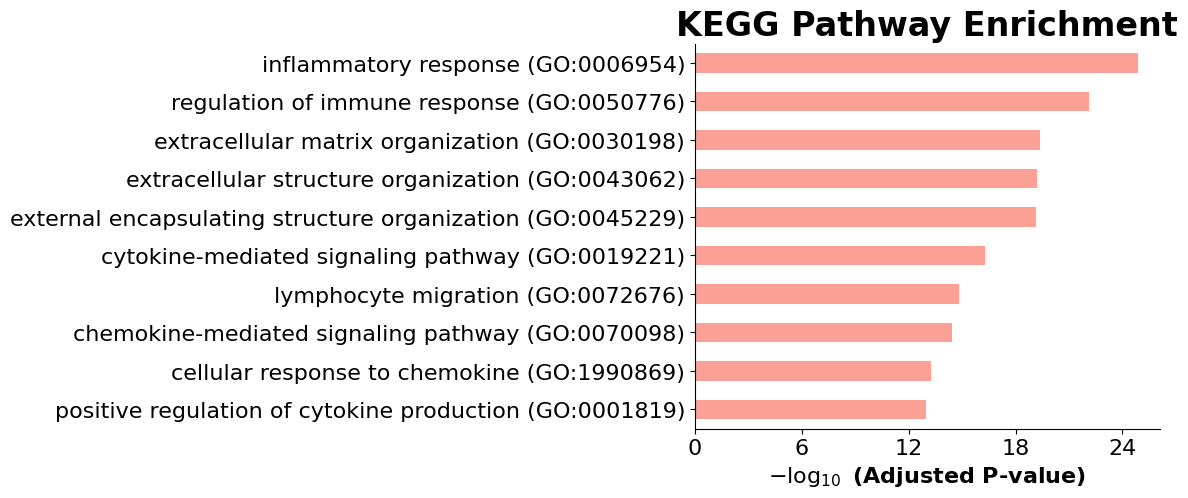

In [112]:
# Visualization of enriched GO terms
# Generate a bar plot of significantly enriched pathways.
# The cutoff ensures only statistically significant terms are shown.
gp.barplot(df=enr.res2d, title='GO Pathway Enrichment', cutoff=0.05, figsize=(6,5))
plt.tight_layout()
plt.show()

In [110]:
list(enr.res2d['Term'][:10])

['inflammatory response (GO:0006954)',
 'regulation of immune response (GO:0050776)',
 'extracellular matrix organization (GO:0030198)',
 'extracellular structure organization (GO:0043062)',
 'external encapsulating structure organization (GO:0045229)',
 'cytokine-mediated signaling pathway (GO:0019221)',
 'lymphocyte migration (GO:0072676)',
 'chemokine-mediated signaling pathway (GO:0070098)',
 'cellular response to chemokine (GO:1990869)',
 'positive regulation of cytokine production (GO:0001819)']